### The University of Melbourne, School of Computing and Information Systems
# COMP90086 Computer Vision, 2025 Semester 2

## Assignment 2

**Student Name:**    `YU LUO`

**Student ID:**     `1528667`

This iPython notebook is a template which you should use for your Assignment 1 submission. This file should be submitted at the **Assignment 2: Code** link on the LMS.

In addition to this file, you should submit a written report explaining your results at the **Assignment 2: Report** link on the LMS. Please see the assignment specification for details on what must be included in the report for each question.

*Adding proper comments to your code is MANDATORY.*

## 1. The image recognition task

In [1]:
# No code is expected for this question

In [2]:
# Global reproducibility
import os, random, numpy as np, tensorflow as tf

SEED = 90086
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"  # deterministic TF ops

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Optional (TensorFlow ≥2.9): enforce determinism
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print(f"Seeds set to {SEED}")

/Users/yuluo/Desktop/UNIMELB/COMP90086/a2/comp90086_env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Seeds set to 90086


## 2. CNN architecture

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Path to the image folders
train_dir = "A2/train"
val_dir = "A2/val"

# Load training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="binary",
    color_mode="grayscale",
    image_size=(28, 28),
    batch_size=64, # mini-batch size
    shuffle=True
)

# Load validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="binary",
    color_mode="grayscale",
    image_size=(28, 28),
    batch_size=64, # mini-batch size
    shuffle=False
)

# Scale pixel values from 0-255 to 0-1
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Optional: cache + prefetch for performance
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomFlip("vertical"),
])

Found 12000 files belonging to 2 classes.
Found 12000 files belonging to 2 classes.


In [4]:
# Function to plot training history
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    # Accuracy plot
    plt.figure(figsize=(6,4))
    plt.plot(epochs, acc, 'b-', label='Training accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    # Loss plot
    plt.figure(figsize=(6,4))
    plt.plot(epochs, loss, 'b-', label='Training loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [5]:
# Define the final model
model = models.Sequential([
    # Input: 28x28 grayscale (1 channel)
    layers.Input(shape=(28, 28, 1)),

    # Apply augmentation only during training
    data_augmentation,

    # Convolutional layers should be added here
    # First Convolutional Layer
    layers.Conv2D(32, (5, 5), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten and dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Print summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       294,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295,873 (1.13 MB)

 Trainable params: 295,873 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

### 2.1 CNN Experiements

#### 2.1.1 Basic Experiements (Kernel Size, Network Depth, Network Width)

##### Model Configurations

In [6]:
cnn_model_configs = [
    # Group 1: Varying Kernel Size in a Single Convolutional Layer
    # Purpose: To investigate how the receptive field size of a single convolutional layer affects model performance.
    # Rationale: The letter patches in the dataset are typically 5, 7, or 9 pixels square, so kernel size may influence the model's ability to capture entire letter shapes versus finer details.
    {
        "name": "1conv_16f_7x7",
        "conv_layers": [
            {"filters": 16, "kernel_size": (7, 7)}
        ],
        # Intuition: A large 7x7 kernel may capture the whole letter shape in one operation,
        # testing whether a single, broad filter is sufficient for the classification task.
    },
    {
        "name": "1conv_16f_5x5",
        "conv_layers": [
            {"filters": 16, "kernel_size": (5, 5)}
        ],
        # Intuition: A 5x5 kernel offers a middle ground, capturing larger features than 3x3
        # but with more focus than 7x7. It may be well-suited for picking up the distinct
        # horizontal and vertical lines that define the letters.
    },
    {
        "name": "1conv_16f_3x3",
        "conv_layers": [
            {"filters": 16, "kernel_size": (3, 3)}
        ],
        # Intuition: A small 3x3 kernel is ideal for detecting fine details such as
        # edges and corners, which are fundamental components of letter shapes. This model
        # tests whether learning from small, local regions is effective for this task.
    },

    # Group 2: Exploring Network Depth and Filter Progression
    # Purpose: To examine how increasing the number of convolutional layers and varying the number of filters per layer
    # affects the model's ability to learn more complex and abstract features.
    {
        "name": "2conv_16f_3x3_16f_3x3",
        "conv_layers": [
            {"filters": 16, "kernel_size": (3, 3)},
            {"filters": 16, "kernel_size": (3, 3)}
        ],
        # Intuition: This model adds a second convolutional layer without increasing the number of filters,
        # isolating the effect of increased depth on feature learning.
        # Tests the benefit of a deeper architecture for capturing complex patterns.
    },
    {
        "name": "2conv_16f_3x3_32f_3x3",
        "conv_layers": [
            {"filters": 16, "kernel_size": (3, 3)},
            {"filters": 32, "kernel_size": (3, 3)}
        ],
        # Intuition: Increasing the filter count in the second layer allows the model to learn more abstract features
        # from the first layer's output. This is a common and effective design pattern in CNNs.
    },
    {
        "name": "2conv_32f_3x3_32f_3x3",
        "conv_layers": [
            {"filters": 32, "kernel_size": (3, 3)},
            {"filters": 32, "kernel_size": (3, 3)}
        ],
        # Intuition: This model uses same kernel size in both layers,
        # aiming for a balance between model complexity and performance.
        
    },
    {
        "name": "2conv_32f_3x3_64f_3x3",
        "conv_layers": [
            {"filters": 32, "kernel_size": (3, 3)},
            {"filters": 64, "kernel_size": (3, 3)}
        ],
        # Intuition: This model uses a more aggressive increase in network width,
        # aiming for a balance between model complexity and performance.
        # Seeks to optimize the trade-off between capacity and overfitting.
    },
    {
        "name": "2conv_64f_3x3_64f_3x3",
        "conv_layers": [
            {"filters": 64, "kernel_size": (3, 3)},
            {"filters": 64, "kernel_size": (3, 3)}
        ],
        # Intuition: A "wide and deep" model that tests whether a larger number of filters
        # in both layers leads to improved accuracy. This high-capacity model may be
        # particularly effective at handling challenging backgrounds, such as random rectangles.
    },
]

In [7]:
# Function to build a model from a given architecture config
def build_model_from_config(config, input_shape=(28, 28, 1)):
    # Build the model as a sequential model
    model = models.Sequential()

    model.add(layers.InputLayer(input_shape=input_shape))
    # Add data augmentation to the input data for better generalisation
    model.add(data_augmentation) 
    # Add convolutional layers as specified in config
    for conv in config['conv_layers']:
        model.add(layers.Conv2D(
            filters=conv['filters'],
            kernel_size=conv['kernel_size'],
            activation='relu', # use relu as the activation function
            padding='same' # same padding means the output size is the same as the input size
        ))
        # Add a consistent (2x2) max pooling layer to reduce the spatial dimensions of the output
        model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model


In [8]:
# Create models from each config and save them in a dictionary
saved_models = {}
for config in cnn_model_configs:
    model = build_model_from_config(config)
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    saved_models[config['name']] = model


/Users/yuluo/Desktop/UNIMELB/COMP90086/a2/comp90086_env/lib/python3.9/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


##### Model Trainning for Experiements

Training model: 1conv_16f_7x7
Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4978 - loss: 0.7004 - val_accuracy: 0.5008 - val_loss: 0.6931
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5040 - loss: 0.6931 - val_accuracy: 0.5002 - val_loss: 0.6931
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4988 - loss: 0.6929 - val_accuracy: 0.5065 - val_loss: 0.6929
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5165 - loss: 0.6927 - val_accuracy: 0.5201 - val_loss: 0.6925
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5208 - loss: 0.6919 - val_accuracy: 0.5286 - val_loss: 0.6909
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5304 - loss: 0.6899 - val_accuracy: 0.5366 - val_loss: 0.6878
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5676 - loss: 0.6799 - val_accuracy: 0.5619 - val_loss: 0.6799
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5949 - l

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 16)     │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 604,901 (2.31 MB)

 Trainable params: 201,633 (787.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 403,268 (1.54 MB)

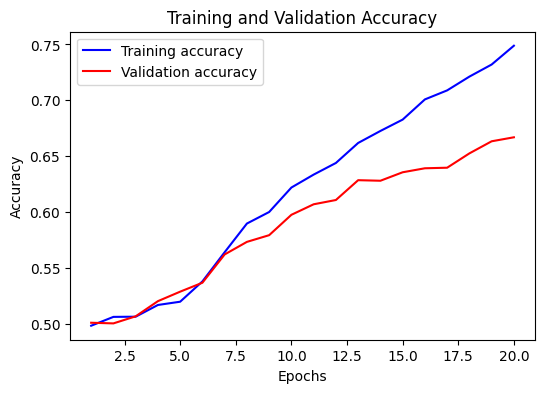

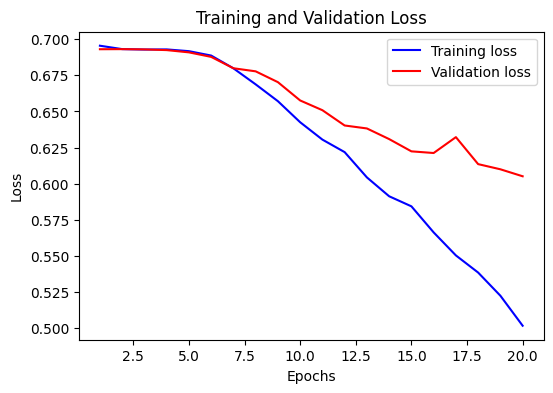

Training model: 1conv_16f_5x5
Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4983 - loss: 0.6992 - val_accuracy: 0.4993 - val_loss: 0.6932
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5038 - loss: 0.6932 - val_accuracy: 0.4981 - val_loss: 0.6932
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4920 - loss: 0.6932 - val_accuracy: 0.5025 - val_loss: 0.6932
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4919 - loss: 0.6934 - val_accuracy: 0.5019 - val_loss: 0.6931
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5165 - loss: 0.6930 - val_accuracy: 0.5063 - val_loss: 0.6930
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5068 - loss: 0.6927 - val_accuracy: 0.5027 - val_loss: 0.6942
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5144 - loss: 0.6922 - val_accuracy: 0.5206 - val_loss: 0.6926
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5386 - l

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 603,749 (2.30 MB)

 Trainable params: 201,249 (786.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 402,500 (1.54 MB)

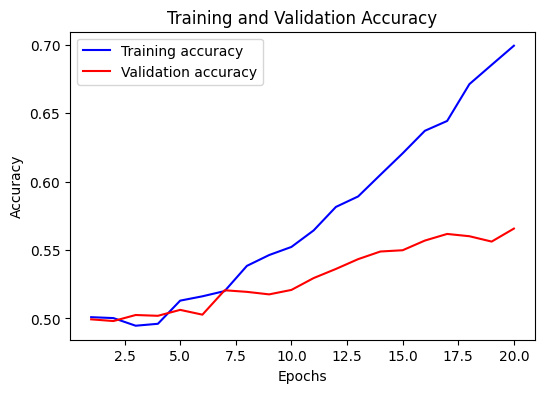

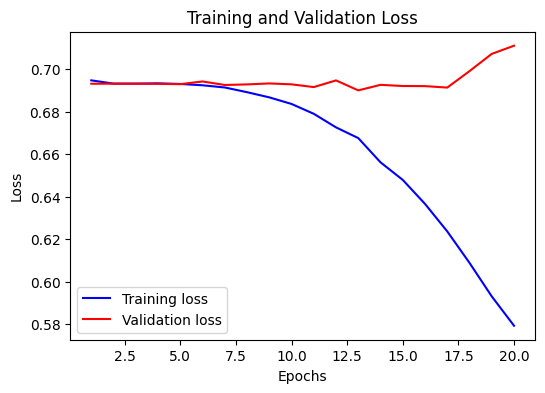

Training model: 1conv_16f_3x3
Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4961 - loss: 0.7043 - val_accuracy: 0.4997 - val_loss: 0.6937
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5035 - loss: 0.6932 - val_accuracy: 0.4989 - val_loss: 0.6932
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4989 - loss: 0.6931 - val_accuracy: 0.5107 - val_loss: 0.6929
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5216 - loss: 0.6923 - val_accuracy: 0.4997 - val_loss: 0.6944
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5350 - loss: 0.6903 - val_accuracy: 0.5059 - val_loss: 0.6956
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5323 - loss: 0.6890 - val_accuracy: 0.5022 - val_loss: 0.6948
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5388 - loss: 0.6883 - val_accuracy: 0.5128 - val_loss: 0.6940
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5641 - l

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 602,981 (2.30 MB)

 Trainable params: 200,993 (785.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 401,988 (1.53 MB)

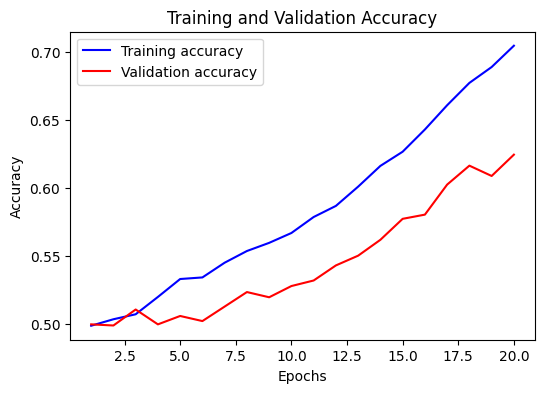

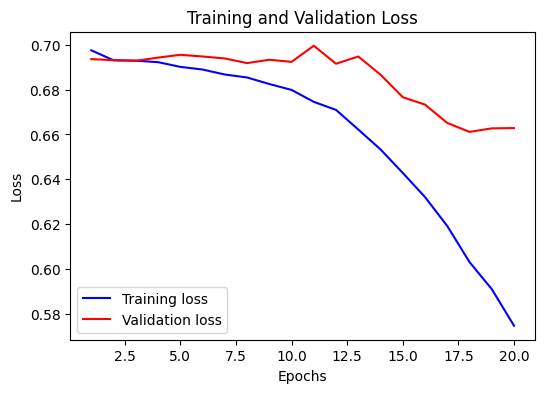

Training model: 2conv_16f_3x3_16f_3x3
Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4993 - loss: 0.6946 - val_accuracy: 0.4944 - val_loss: 0.6933
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5107 - loss: 0.6931 - val_accuracy: 0.5004 - val_loss: 0.6931
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5094 - loss: 0.6930 - val_accuracy: 0.5142 - val_loss: 0.6930
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5189 - loss: 0.6923 - val_accuracy: 0.5011 - val_loss: 0.6943
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5161 - loss: 0.6921 - val_accuracy: 0.5251 - val_loss: 0.6914
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5428 - loss: 0.6882 - val_accuracy: 0.5587 - val_loss: 0.6831
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5666 - loss: 0.6782 - val_accuracy: 0.5720 - val_loss: 0.6824
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,357 (618.59 KB)

 Trainable params: 52,785 (206.19 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 105,572 (412.39 KB)

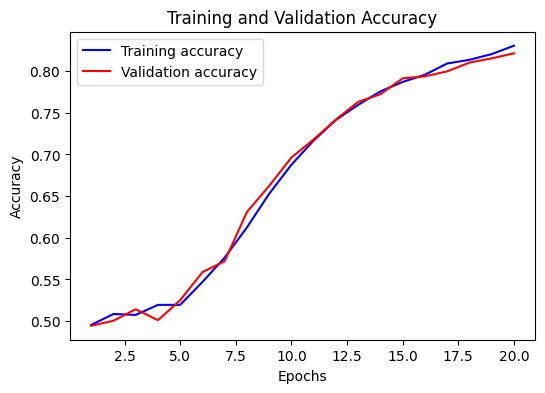

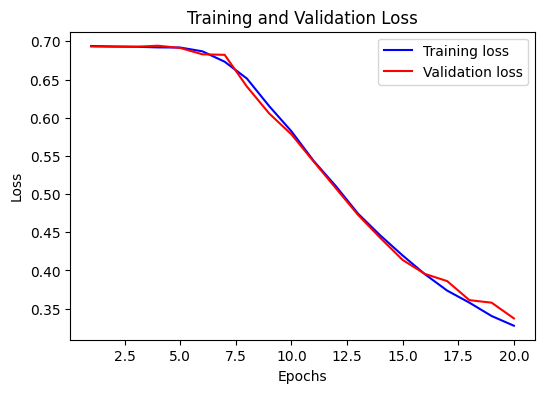

Training model: 2conv_16f_3x3_32f_3x3
Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4980 - loss: 0.6968 - val_accuracy: 0.5001 - val_loss: 0.6931
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4976 - loss: 0.6932 - val_accuracy: 0.5037 - val_loss: 0.6928
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5104 - loss: 0.6929 - val_accuracy: 0.5284 - val_loss: 0.6915
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5325 - loss: 0.6897 - val_accuracy: 0.5583 - val_loss: 0.6856
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5665 - loss: 0.6795 - val_accuracy: 0.6005 - val_loss: 0.6660
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6220 - loss: 0.6506 - val_accuracy: 0.6373 - val_loss: 0.6399
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6511 - loss: 0.6234 - val_accuracy: 0.6812 - val_loss: 0.5992
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,845 (1.20 MB)

 Trainable params: 105,281 (411.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 210,564 (822.52 KB)

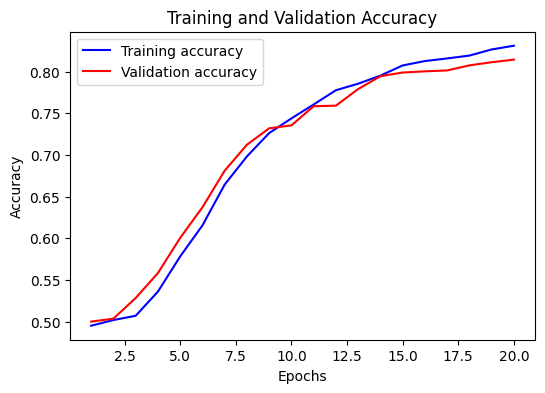

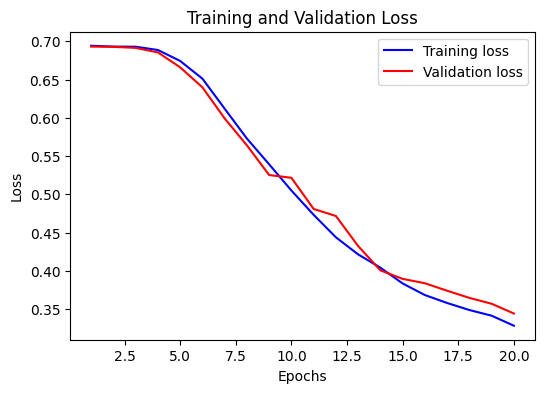

Training model: 2conv_32f_3x3_32f_3x3
Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4973 - loss: 0.6956 - val_accuracy: 0.5076 - val_loss: 0.6931
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5101 - loss: 0.6930 - val_accuracy: 0.4991 - val_loss: 0.6931
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5038 - loss: 0.6931 - val_accuracy: 0.5288 - val_loss: 0.6917
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5344 - loss: 0.6900 - val_accuracy: 0.5422 - val_loss: 0.6881
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5643 - loss: 0.6817 - val_accuracy: 0.5474 - val_loss: 0.6864
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5900 - loss: 0.6681 - val_accuracy: 0.6173 - val_loss: 0.6446
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6375 - loss: 0.6295 - val_accuracy: 0.6480 - val_loss: 0.6159
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accu

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 330,149 (1.26 MB)

 Trainable params: 110,049 (429.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 220,100 (859.77 KB)

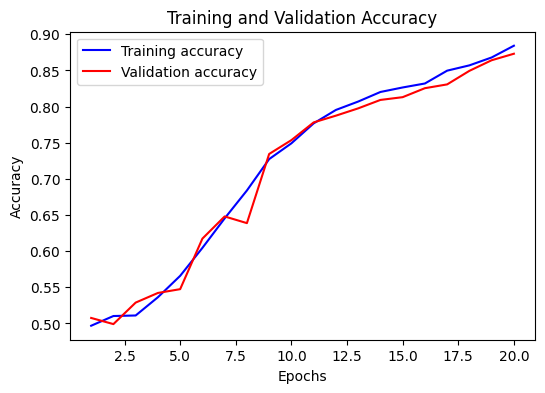

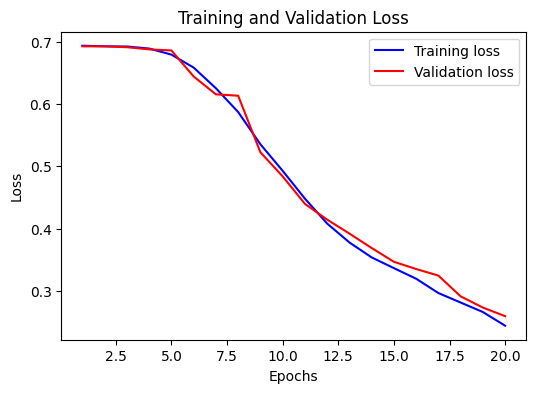

Training model: 2conv_32f_3x3_64f_3x3
Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4969 - loss: 0.6958 - val_accuracy: 0.5028 - val_loss: 0.6931
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5015 - loss: 0.6933 - val_accuracy: 0.5303 - val_loss: 0.6927
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5220 - loss: 0.6919 - val_accuracy: 0.5467 - val_loss: 0.6852
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5689 - loss: 0.6784 - val_accuracy: 0.6135 - val_loss: 0.6527
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6337 - loss: 0.6407 - val_accuracy: 0.6541 - val_loss: 0.6104
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6937 - loss: 0.5859 - val_accuracy: 0.7103 - val_loss: 0.5554
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7317 - loss: 0.5363 - val_accuracy: 0.7062 - val_loss: 0.5400
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accu

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 658,949 (2.51 MB)

 Trainable params: 219,649 (858.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 439,300 (1.68 MB)

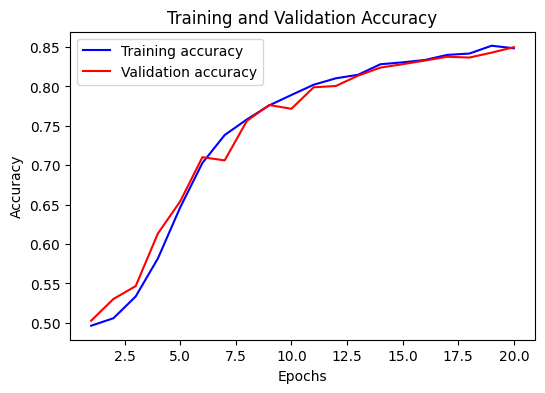

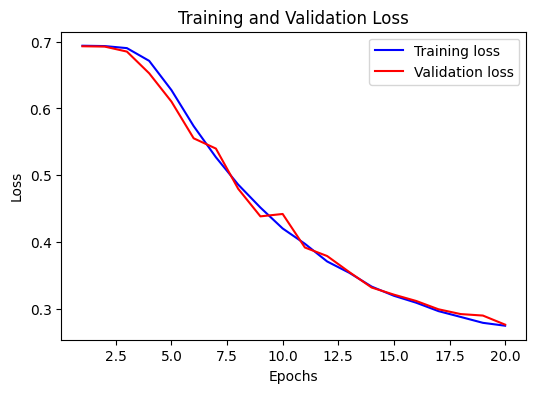

Training model: 2conv_64f_3x3_64f_3x3
Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.5026 - loss: 0.6947 - val_accuracy: 0.5012 - val_loss: 0.6931
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.5017 - loss: 0.6932 - val_accuracy: 0.5293 - val_loss: 0.6925
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5351 - loss: 0.6913 - val_accuracy: 0.5211 - val_loss: 0.6915
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5508 - loss: 0.6848 - val_accuracy: 0.5794 - val_loss: 0.6706
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6025 - loss: 0.6620 - val_accuracy: 0.6234 - val_loss: 0.6412
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6417 - loss: 0.6311 - val_accuracy: 0.6525 - val_loss: 0.6148
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6753 - loss: 0.5974 - val_accuracy: 0.6708 - val_loss: 0.5960
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accu

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 715,205 (2.73 MB)

 Trainable params: 238,401 (931.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 476,804 (1.82 MB)

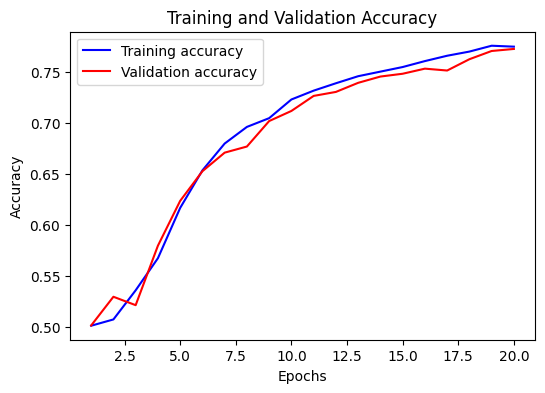

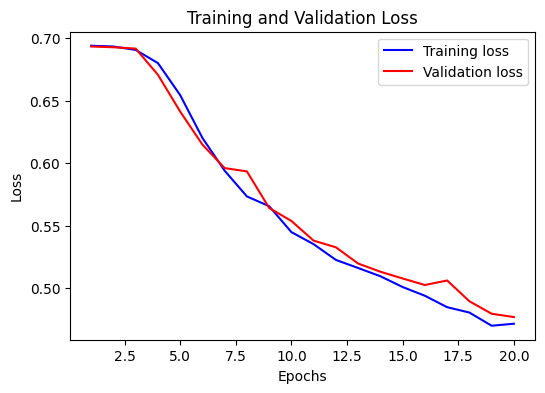


Experiment Results (Final Validation Accuracy):
1conv_16f_7x7: Final Validation Accuracy = 0.6668
1conv_16f_5x5: Final Validation Accuracy = 0.5657
1conv_16f_3x3: Final Validation Accuracy = 0.6245
2conv_16f_3x3_16f_3x3: Final Validation Accuracy = 0.8215
2conv_16f_3x3_32f_3x3: Final Validation Accuracy = 0.8145
2conv_32f_3x3_32f_3x3: Final Validation Accuracy = 0.8731
2conv_32f_3x3_64f_3x3: Final Validation Accuracy = 0.8498
2conv_64f_3x3_64f_3x3: Final Validation Accuracy = 0.7725


In [9]:
# Given the relatively small size of the dataset, we set the number of epochs to 20 
# to ensure the model has enough time to learn the patterns in the data.
histories = {}
for model_name, model in saved_models.items():
    print(f"Training model: {model_name}")
    # Re-Compile to reset optimizer state before training
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    history = model.fit(
        train_ds,
        epochs=20,
        batch_size=64,
        validation_data=val_ds
    )
    histories[model_name] = history
    print(f"Model: {model_name}")
    model.summary()
    plot_history(history)

# Report experiment results
print("\nExperiment Results (Final Validation Accuracy):")
for model_name, history in histories.items():
    val_acc = history.history['val_accuracy'][-1]
    print(f"{model_name}: Final Validation Accuracy = {val_acc:.4f}")


In [10]:
# Print out the parameter number as well before the accuracy
print("\nExperiment Results (Final Validation Accuracy and Parameter Count):")
for model_name, history in histories.items():
    val_acc = history.history['val_accuracy'][-1]
    # Get parameter count from the model
    param_count = saved_models[model_name].count_params()
    print(f"{model_name}: Params = {param_count:,} | Final Validation Accuracy = {val_acc:.4f}")



Experiment Results (Final Validation Accuracy and Parameter Count):
1conv_16f_7x7: Params = 201,633 | Final Validation Accuracy = 0.6668
1conv_16f_5x5: Params = 201,249 | Final Validation Accuracy = 0.5657
1conv_16f_3x3: Params = 200,993 | Final Validation Accuracy = 0.6245
2conv_16f_3x3_16f_3x3: Params = 52,785 | Final Validation Accuracy = 0.8215
2conv_16f_3x3_32f_3x3: Params = 105,281 | Final Validation Accuracy = 0.8145
2conv_32f_3x3_32f_3x3: Params = 110,049 | Final Validation Accuracy = 0.8731
2conv_32f_3x3_64f_3x3: Params = 219,649 | Final Validation Accuracy = 0.8498
2conv_64f_3x3_64f_3x3: Params = 238,401 | Final Validation Accuracy = 0.7725


##### Experiement Results

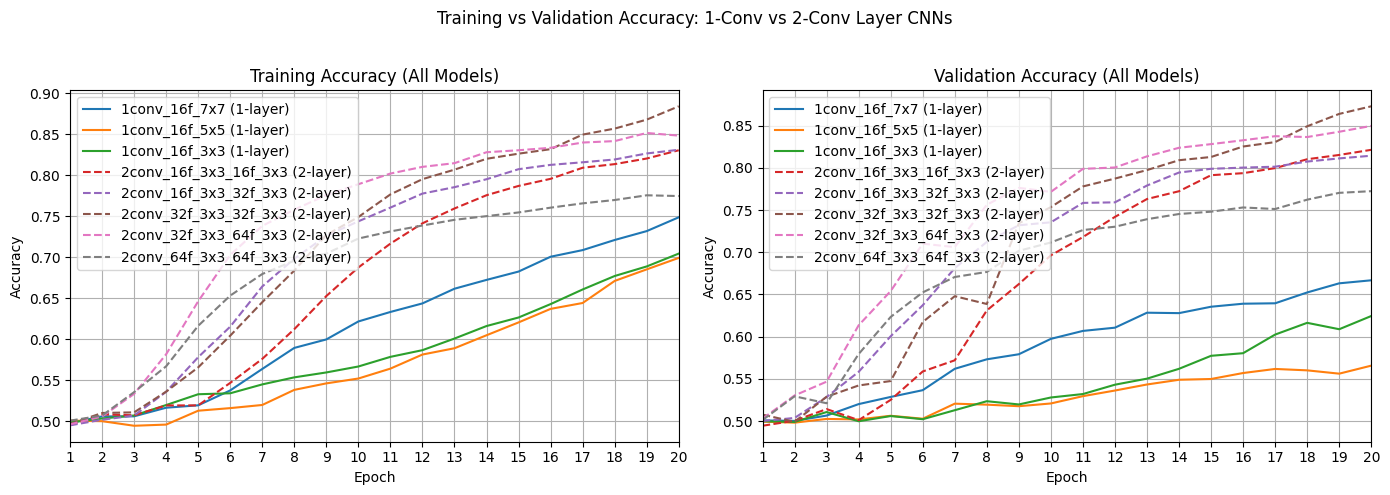

In [11]:
 
# Identify 1-conv and 2-conv models by their names
one_conv_names = [name for name in histories if name.startswith('1conv')]
two_conv_names = [name for name in histories if name.startswith('2conv')]

plt.figure(figsize=(14, 5))

# Get number of epochs from any history (all should be the same)
n_epochs = len(next(iter(histories.values())).history['accuracy'])
epochs = list(range(1, n_epochs + 1))  # Now epochs are 1-based: [1, 2, ..., 10]

# First plot: Training accuracy only, overlay all models, distinguish by 1-layer/2-layer
plt.subplot(1, 2, 1)
for name in one_conv_names:
    plt.plot(epochs, histories[name].history['accuracy'], label=f"{name} (1-layer)", linestyle='-')
for name in two_conv_names:
    plt.plot(epochs, histories[name].history['accuracy'], label=f"{name} (2-layer)", linestyle='--')
plt.title("Training Accuracy (All Models)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xlim(1, n_epochs)
plt.xticks(epochs)
plt.legend()
plt.grid(True)

# Second plot: Validation accuracy only, overlay all models, distinguish by 1-layer/2-layer
plt.subplot(1, 2, 2)
for name in one_conv_names:
    plt.plot(epochs, histories[name].history['val_accuracy'], label=f"{name} (1-layer)", linestyle='-')
for name in two_conv_names:
    plt.plot(epochs, histories[name].history['val_accuracy'], label=f"{name} (2-layer)", linestyle='--')
plt.title("Validation Accuracy (All Models)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xlim(1, n_epochs)
plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.suptitle("Training vs Validation Accuracy: 1-Conv vs 2-Conv Layer CNNs")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


#### 2.1.2 Second Experiements (Based on 2_conv_32f)

In [12]:
cnn_model_configs_combined = [
    {
        "name": "2conv_32f_5x5_32f_3x3",
        "conv_layers": [
            {"filters": 32, "kernel_size": (5, 5)},
            {"filters": 32, "kernel_size": (3, 3)}
        ],
        # 32->32 filters, 5x5 then 3x3 kernels
    },
    {
        "name": "2conv_32f_7x7_32f_5x5",
        "conv_layers": [
            {"filters": 32, "kernel_size": (7, 7)},
            {"filters": 32, "kernel_size": (5, 5)}
        ],
        # 32->32 filters, 7x7 then 5x5 kernels
    },
    {
        "name": "2conv_32f_7x7_32f_3x3",
        "conv_layers": [
            {"filters": 32, "kernel_size": (7, 7)},
            {"filters": 32, "kernel_size": (3, 3)}
        ],
        # 32->32 filters, 7x7 then 3x3 kernels
    }
]


Training model: 2conv_32f_5x5_32f_3x3
Epoch 1/20


/Users/yuluo/Desktop/UNIMELB/COMP90086/a2/comp90086_env/lib/python3.9/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5094 - loss: 0.6948 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5016 - loss: 0.6932 - val_accuracy: 0.5033 - val_loss: 0.6931
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5075 - loss: 0.6932 - val_accuracy: 0.5057 - val_loss: 0.6931
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5050 - loss: 0.6931 - val_accuracy: 0.5419 - val_loss: 0.6893
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5514 - loss: 0.6863 - val_accuracy: 0.6143 - val_loss: 0.6589
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6268 - loss: 0.6459 - val_accuracy: 0.6935 - val_loss: 0.5853
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7031 - loss: 0.5662 - val_accuracy: 0.7434 - val_loss: 0.5178
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7631 - loss: 0.4840 - val_accuracy: 0.7887 -

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 331,685 (1.27 MB)

 Trainable params: 110,561 (431.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 221,124 (863.77 KB)

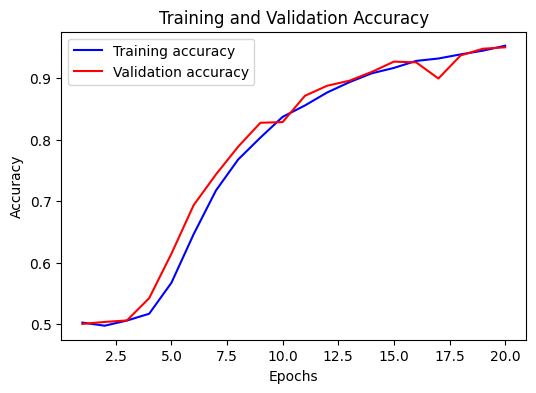

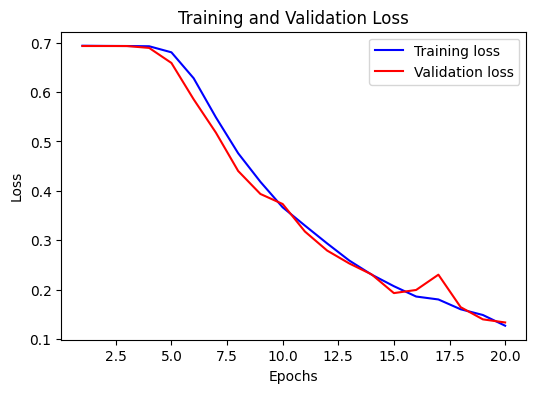

Training model: 2conv_32f_7x7_32f_5x5
Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4884 - loss: 0.6947 - val_accuracy: 0.4998 - val_loss: 0.6932
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4953 - loss: 0.6932 - val_accuracy: 0.4999 - val_loss: 0.6931
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4976 - loss: 0.6932 - val_accuracy: 0.4992 - val_loss: 0.6931
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5084 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5029 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5022 - loss: 0.6932 - val_accuracy: 0.4999 - val_loss: 0.6931
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4933 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accu

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 28, 28, 32)     │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 14, 14, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 383,141 (1.46 MB)

 Trainable params: 127,713 (498.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 255,428 (997.77 KB)

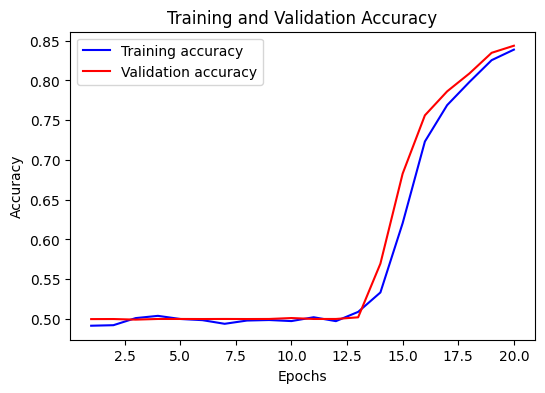

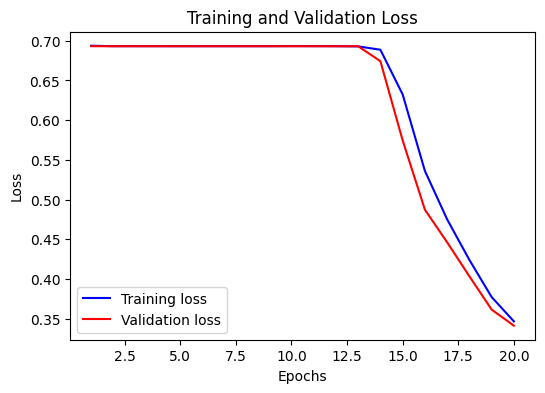

Training model: 2conv_32f_7x7_32f_3x3
Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4953 - loss: 0.6946 - val_accuracy: 0.5041 - val_loss: 0.6931
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4987 - loss: 0.6932 - val_accuracy: 0.5025 - val_loss: 0.6931
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5006 - loss: 0.6932 - val_accuracy: 0.5074 - val_loss: 0.6931
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5101 - loss: 0.6931 - val_accuracy: 0.5165 - val_loss: 0.6927
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5095 - loss: 0.6930 - val_accuracy: 0.5106 - val_loss: 0.6921
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5196 - loss: 0.6926 - val_accuracy: 0.5453 - val_loss: 0.6864
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5675 - loss: 0.6785 - val_accuracy: 0.6846 - val_loss: 0.5826
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accu

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 28, 28, 32)     │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,989 (1.27 MB)

 Trainable params: 111,329 (434.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 222,660 (869.77 KB)

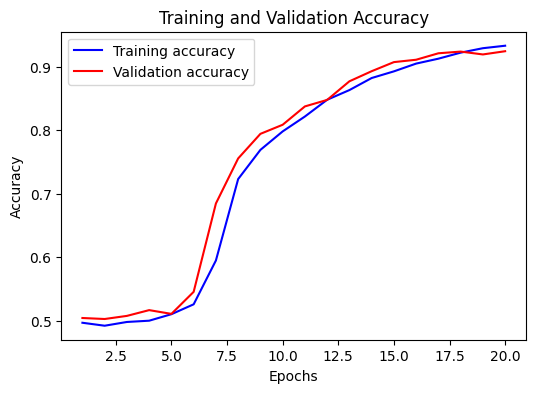

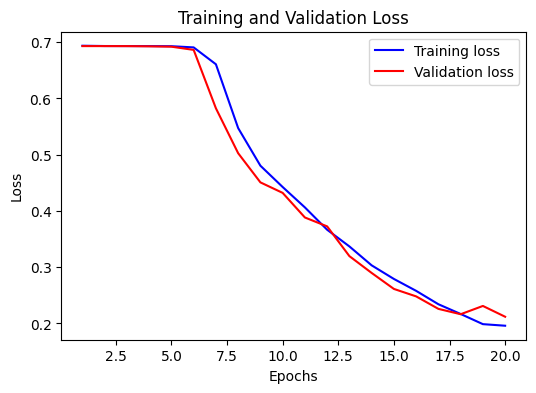

In [25]:
# Given the relatively small size of the dataset, we set the number of epochs to 20 
# to ensure the model has enough time to learn the patterns in the data.
second_histories = {}
for config in cnn_model_configs_combined:
    print(f"Training model: {config['name']}")
    model = build_model_from_config(config)
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    history = model.fit(
        train_ds,
        epochs=20,
        batch_size=64,
        validation_data=val_ds,
        verbose=1
    )
    saved_models[config['name']] = model # save the model
    second_histories[config['name']] = history # save the training history
    print(f"Model: {config['name']}")
    model.summary()
    plot_history(history)



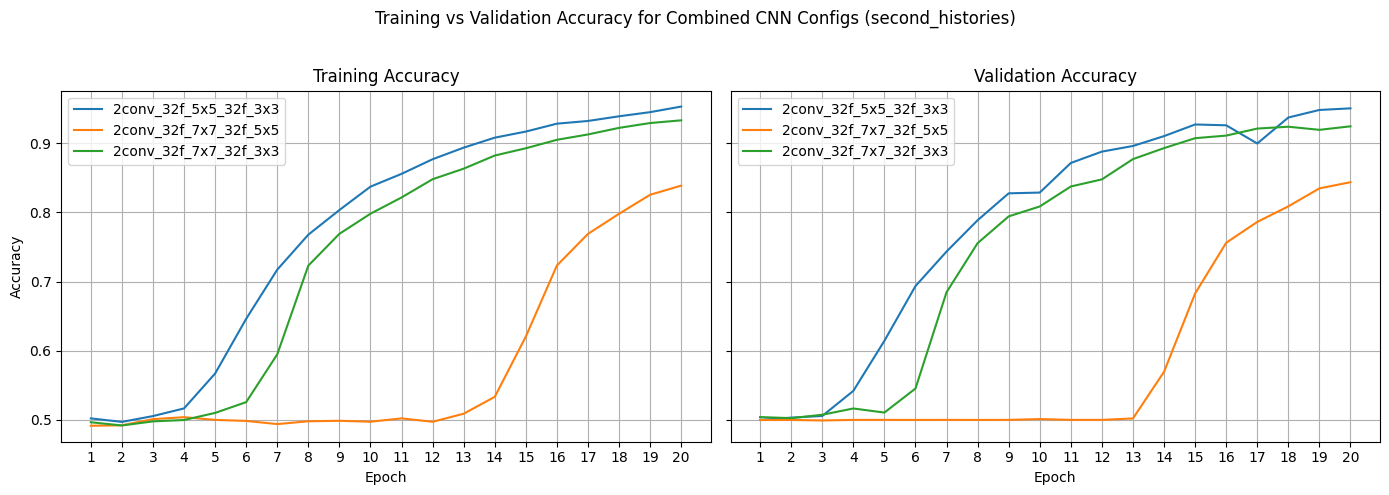

Model: 2conv_32f_5x5_32f_3x3
  Final Training Accuracy: 0.9532
  Final Validation Accuracy: 0.9506
  Total Parameters: 110561
----------------------------------------
Model: 2conv_32f_7x7_32f_5x5
  Final Training Accuracy: 0.8388
  Final Validation Accuracy: 0.8438
  Total Parameters: 127713
----------------------------------------
Model: 2conv_32f_7x7_32f_3x3
  Final Training Accuracy: 0.9333
  Final Validation Accuracy: 0.9246
  Total Parameters: 111329
----------------------------------------


In [27]:
# Plot training and validation accuracy for the two new CNN configs side by side using second_histories

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for config in cnn_model_configs_combined:
    history = second_histories[config['name']]
    axes[0].plot(range(1, len(history.history['accuracy']) + 1), history.history['accuracy'], label=f"{config['name']}")
    axes[1].plot(range(1, len(history.history['val_accuracy']) + 1), history.history['val_accuracy'], label=f"{config['name']}")

axes[0].set_title("Training Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticks(range(1, 21))
axes[0].legend()
axes[0].grid(True)

axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_xticks(range(1, 21))
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Training vs Validation Accuracy for Combined CNN Configs (second_histories)")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Print out the final accuracy and parameter count for each model in cnn_model_configs_combined

for config in cnn_model_configs_combined:
    model = saved_models[config['name']]
    history = second_histories[config['name']]
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    param_count = model.count_params()
    print(f"Model: {config['name']}")
    print(f"  Final Training Accuracy: {final_train_acc:.4f}")
    print(f"  Final Validation Accuracy: {final_val_acc:.4f}")
    print(f"  Total Parameters: {param_count}")
    print("-" * 40)



#### Padding vs. No Padding

Epoch 1/20


188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5028 - loss: 0.6937 - val_accuracy: 0.5002 - val_loss: 0.6932
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5039 - loss: 0.6933 - val_accuracy: 0.5001 - val_loss: 0.6939
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5019 - loss: 0.6935 - val_accuracy: 0.4997 - val_loss: 0.6932
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5021 - loss: 0.6933 - val_accuracy: 0.5033 - val_loss: 0.6931
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5044 - loss: 0.6932 - val_accuracy: 0.4997 - val_loss: 0.6931
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5048 - loss: 0.6931 - val_accuracy: 0.4999 - val_loss: 0.6947
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5254 - loss: 0.6926 - val_accuracy: 0.5117 - val_loss: 0.6911
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5508 - loss: 0.6835 - val_accuracy: 0.6062 - val_

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 10, 10, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,229 (719.65 KB)

 Trainable params: 61,409 (239.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 122,820 (479.77 KB)

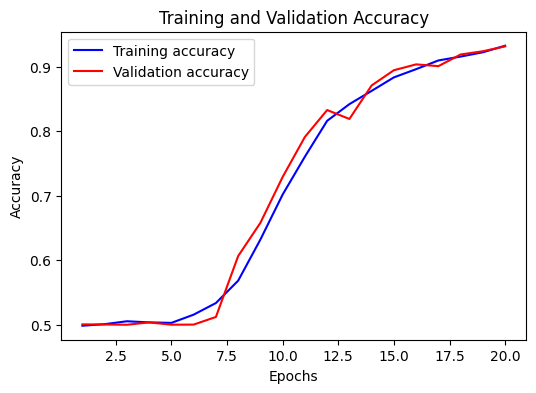

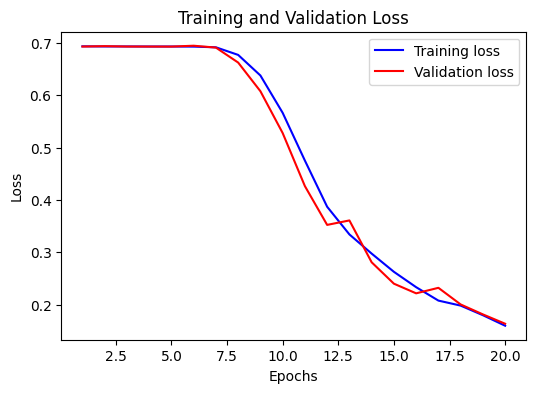

In [34]:
# Define the final model with 'valid' padding
model_valid_padding = models.Sequential([
    # Input: 28x28 grayscale (1 channel)
    layers.Input(shape=(28, 28, 1)),

    # Apply augmentation only during training
    data_augmentation,

    # First Convolutional Layer with 'valid' padding
    layers.Conv2D(32, (5, 5), activation='relu', padding='valid'),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Layer with 'valid' padding
    layers.Conv2D(32, (3, 3), activation='relu', padding='valid'),
    layers.MaxPooling2D((2, 2)),

    # Flatten and dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
model_valid_padding.compile(optimizer='adam',
                           loss='binary_crossentropy',
                           metrics=['accuracy'])

history_valid_padding = model_valid_padding.fit(
    train_ds,
    epochs=20,
    batch_size=64,
    validation_data=val_ds,
    verbose=1
)

# Show summary and plot history
model_valid_padding.summary()
plot_history(history_valid_padding)


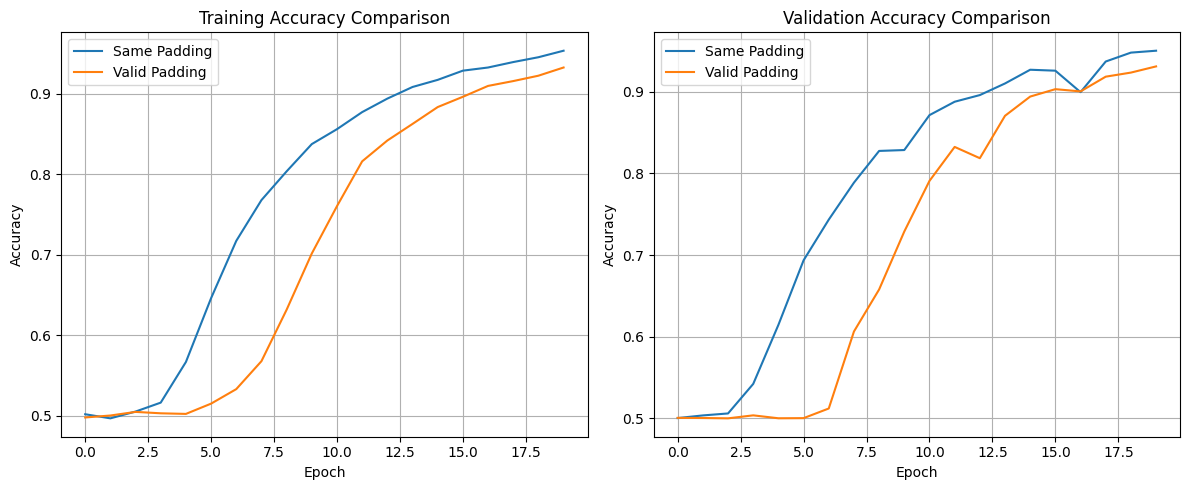

Same Padding Model - Final Validation Accuracy: 0.9506, Parameters: 110561
Valid Padding Model - Final Validation Accuracy: 0.9313, Parameters: 61409


In [36]:
history_valid_padding = history_valid_padding

history_same_padding = second_histories['2conv_32f_5x5_32f_3x3']
model_same_padding = saved_models['2conv_32f_5x5_32f_3x3']

# Compare training accuracy for both models
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_same_padding.history['accuracy'], label='Same Padding')
plt.plot(history_valid_padding.history['accuracy'], label='Valid Padding')
plt.title('Training Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Compare validation accuracy for both models
plt.subplot(1, 2, 2)
plt.plot(history_same_padding.history['val_accuracy'], label='Same Padding')
plt.plot(history_valid_padding.history['val_accuracy'], label='Valid Padding')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print out final validation accuracy and parameter count for both models
final_acc_same = history_same_padding.history['val_accuracy'][-1]
final_acc_valid = history_valid_padding.history['val_accuracy'][-1]

# Assuming you have access to both models: model_valid_padding and model_same_padding
# If model_same_padding is not defined, you may need to define it or retrieve it accordingly
try:
    params_same = model_same_padding.count_params()
except NameError:
    params_same = "N/A (model_same_padding not defined)"
params_valid = model_valid_padding.count_params()

print(f"Same Padding Model - Final Validation Accuracy: {final_acc_same:.4f}, Parameters: {params_same}")
print(f"Valid Padding Model - Final Validation Accuracy: {final_acc_valid:.4f}, Parameters: {params_valid}")


#### 2.1 Final Model

Epoch 1/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4986 - loss: 0.6942 - val_accuracy: 0.4958 - val_loss: 0.6931
Epoch 2/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5089 - loss: 0.6932 - val_accuracy: 0.4998 - val_loss: 0.6931
Epoch 3/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5058 - loss: 0.6931 - val_accuracy: 0.5012 - val_loss: 0.6931
Epoch 4/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4947 - loss: 0.6932 - val_accuracy: 0.5040 - val_loss: 0.6931
Epoch 5/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5041 - loss: 0.6931 - val_accuracy: 0.5173 - val_loss: 0.6930
Epoch 6/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5058 - loss: 0.6930 - val_accuracy: 0.5111 - val_loss: 0.6925
Epoch 7/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5093 - loss: 0.6925 - val_accuracy: 0.5298 - val_loss: 0.6910
Epoch 8/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5462 - loss: 0.6884 - val_accuracy: 0.

Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 10, 10, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_27 (Flatten)            │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 32)             │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,237 (418.90 KB)

 Trainable params: 35,745 (139.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 71,492 (279.27 KB)

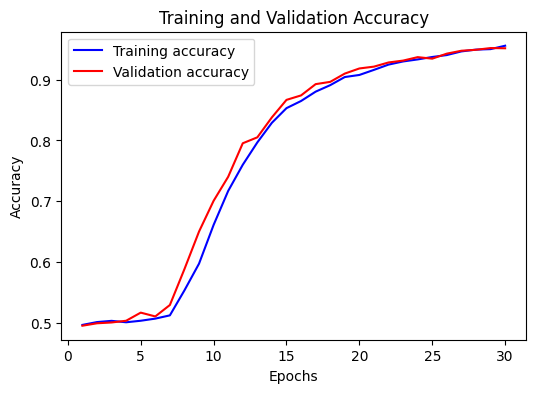

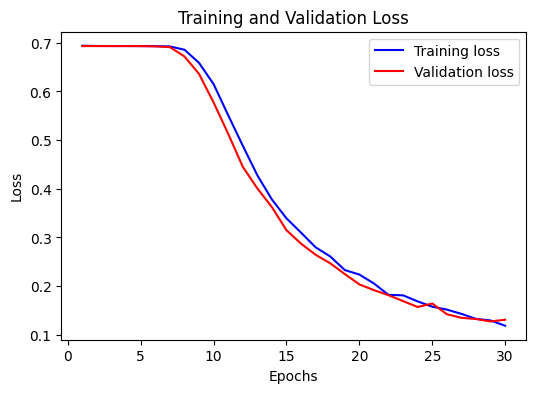

In [51]:
# Define the final model
final_model = models.Sequential([
    # Input: 28x28 grayscale (1 channel)
    layers.Input(shape=(28, 28, 1)),

    # Apply augmentation only during training
    data_augmentation,

    # Convolutional layers should be added here
    # First Convolutional Layer
    layers.Conv2D(32, (5, 5), activation='relu', padding='valid'),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Layer
    layers.Conv2D(32, (3, 3), activation='relu', padding='valid'),
    layers.MaxPooling2D((2, 2)),

    # Flatten and dense layers
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.5), # drop out rate is 0.5 to prevent overfitting
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
final_model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

final_history = final_model.fit(
        train_ds,
        epochs=30,
        batch_size=64,
        validation_data=val_ds,
        verbose=1
    )

final_model.summary()
plot_history(final_history)

### 3. Kernel visualisation

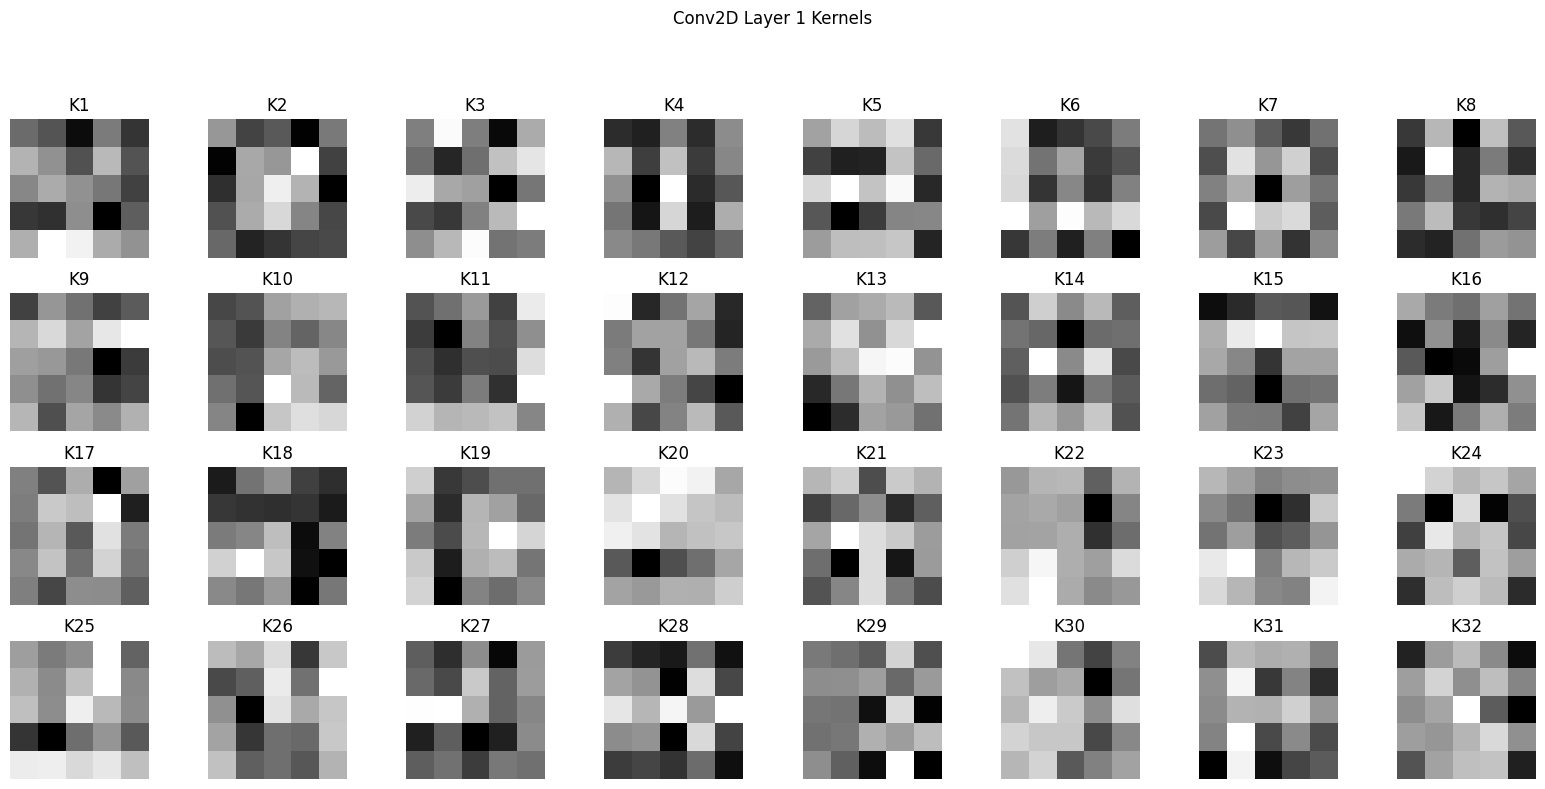

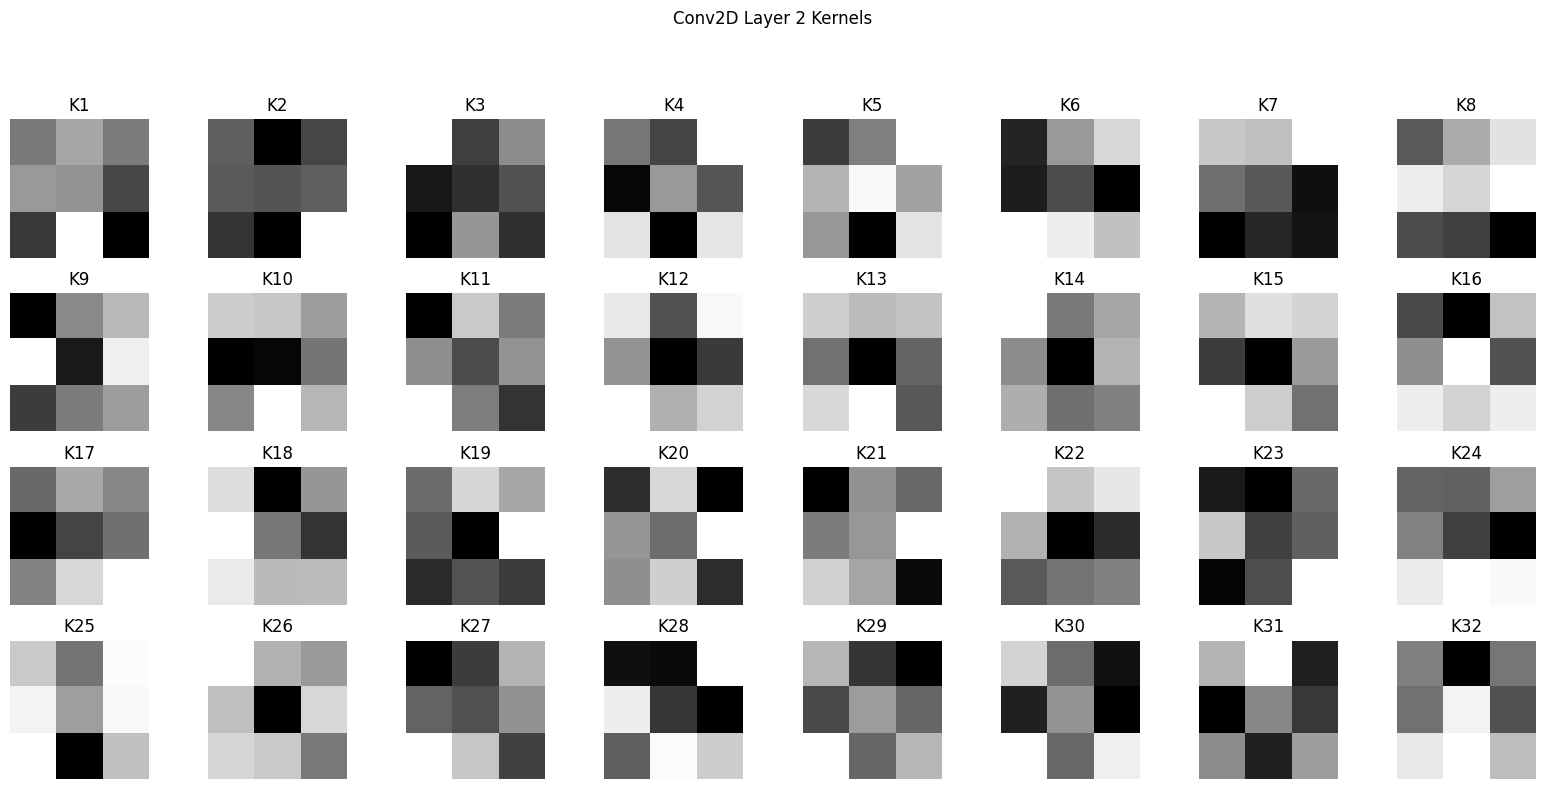

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Find the first and second Conv2D layers in the final_model
conv_layers = [layer for layer in final_model.layers if isinstance(layer, layers.Conv2D)]

if len(conv_layers) < 2:
    raise ValueError("Model does not have two Conv2D layers.")

# Visualize kernels for both Conv2D layers
for idx, conv_layer in enumerate(conv_layers[:2]):
    kernels, biases = conv_layer.get_weights()
    num_kernels = kernels.shape[-1]
    # Normalize kernels for visualization
    kernels_min = kernels.min()
    kernels_max = kernels.max()
    kernels_norm = (kernels - kernels_min) / (kernels_max - kernels_min + 1e-5)
    
    # Set up grid size
    n_cols = min(num_kernels, 8)
    n_rows = int(np.ceil(num_kernels / n_cols))
    plt.figure(figsize=(2*n_cols, 2*n_rows))
    for i in range(num_kernels):
        plt.subplot(n_rows, n_cols, i + 1)
        # Show only the first input channel (since input is grayscale or single channel)
        plt.imshow(kernels_norm[:, :, 0, i], cmap='gray')
        plt.axis('off')
        plt.title(f'K{i+1}')
    plt.suptitle(f'Conv2D Layer {idx+1} Kernels')
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


### 4. Where is the model looking?

In [70]:
import numpy as np
import tensorflow as tf

def compute_gradcam_optimized(model: tf.keras.Model,
                              img_array: np.ndarray,
                              upsample_size=(28, 28)) -> np.ndarray:
    """
    使用优化的方法计算 Grad-CAM 热力图.

    Args:
        model: 训练好的 Keras 模型。
        img_array: (H, W) 或 (H, W, 1) 的灰度输入图像。
        upsample_size: 将热力图双线性上采样到的尺寸 (h, w)。

    Returns:
        heatmap: 归一化到 [0,1]、大小为 upsample_size 的热力图 (np.ndarray)。
    """
    # 0) 规范输入到 (1,H,W,1) 且 [0,1]
    x = img_array
    if x.ndim == 2:
        x = x[..., None]
    x = x.astype("float32")
    if x.max() > 1.0:
        x = x / 255.0
    x = x[None, ...]  # (1,H,W,1)

    # 1) 找到最后一个 Conv2D 层
    last_conv_layer = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer = layer
            break
    if last_conv_layer is None:
        raise ValueError("模型中未找到卷积层。")
    last_conv_layer_name = last_conv_layer.name

    # 确保模型已构建（避免“never been called”错误）
    _ = model(x, training=False)

    # 2) 模型1：输入 -> 最后卷积层输出
    grad_model_1 = tf.keras.models.Model(
        [model.inputs], [last_conv_layer.output]
    )

    # 3) 模型2：最后卷积层输出 -> 最终预测（把后续层串起来）
    last_idx = model.layers.index(last_conv_layer)
    conv_out_shape = last_conv_layer.output.shape[1:]  # (h,w,c)
    conv_input = tf.keras.Input(shape=conv_out_shape)
    t = conv_input
    for i in range(last_idx + 1, len(model.layers)):
        t = model.layers[i](t)
    grad_model_2 = tf.keras.models.Model([conv_input], [t])

    # 4) 计算梯度并生成热力图
    with tf.GradientTape() as tape:
        conv_outputs = grad_model_1(x)           # (1,h,w,c)
        tape.watch(conv_outputs)
        preds = grad_model_2(conv_outputs)       # (1,num_classes) 或 (1,1)
        if preds.shape[-1] == 1:                 # 二分类 (sigmoid)
            loss = preds[:, 0]
        else:                                    # 多分类 (softmax)
            cls_idx = tf.argmax(preds[0])
            loss = preds[:, cls_idx]

    grads = tape.gradient(loss, conv_outputs)             # (1,h,w,c)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # (c,)
    conv_outputs = conv_outputs[0]                        # (h,w,c)
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)  # (h,w)

    # 5) ReLU、归一化、上采样
    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    heatmap = tf.image.resize(heatmap[..., tf.newaxis],
                              upsample_size, method='bilinear')[..., 0]
    return tf.squeeze(heatmap).numpy()


In [73]:
def plot_samples_with_gradcam(model: tf.keras.Model, samples: list, class_name: str, cols=5):
    """
    在一个网格图中可视化多个样本的 Grad-CAM 结果。
    """
    num_samples = len(samples)
    rows = (num_samples + 2 * cols - 1) // cols

    plt.figure(figsize=(cols * 2.5, rows * 2.5))
    plt.suptitle(f"Grad-CAM Visualization for Class: '{class_name}'", fontsize=16, y=1.02)

    for i, img in enumerate(samples):
        # 计算热力图
        heatmap = compute_gradcam_optimized(model, img, upsample_size=(28, 28))

        # 准备叠加图像
        base = img.squeeze()
        if base.max() > 1.0: base = base / 255.0
        hm_rgb = plt.cm.jet(heatmap)[..., :3]
        overlay = 0.6 * np.stack([base, base, base], axis=-1) + 0.4 * hm_rgb
        overlay = np.clip(overlay, 0, 1)

        # 绘制原始图像
        ax = plt.subplot(rows, cols, 2 * i + 1)
        ax.imshow(img.squeeze(), cmap='gray')
        ax.set_title(f'Input #{i+1}')
        ax.axis('off')

        # 绘制叠加了热力图的图像
        ax = plt.subplot(rows, cols, 2 * i + 2)
        ax.imshow(overlay)
        ax.set_title(f'Overlay #{i+1}')
        ax.axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

为 Grad-CAM 收集到 5 个 'L' 样本和 5 个 'T' 样本。


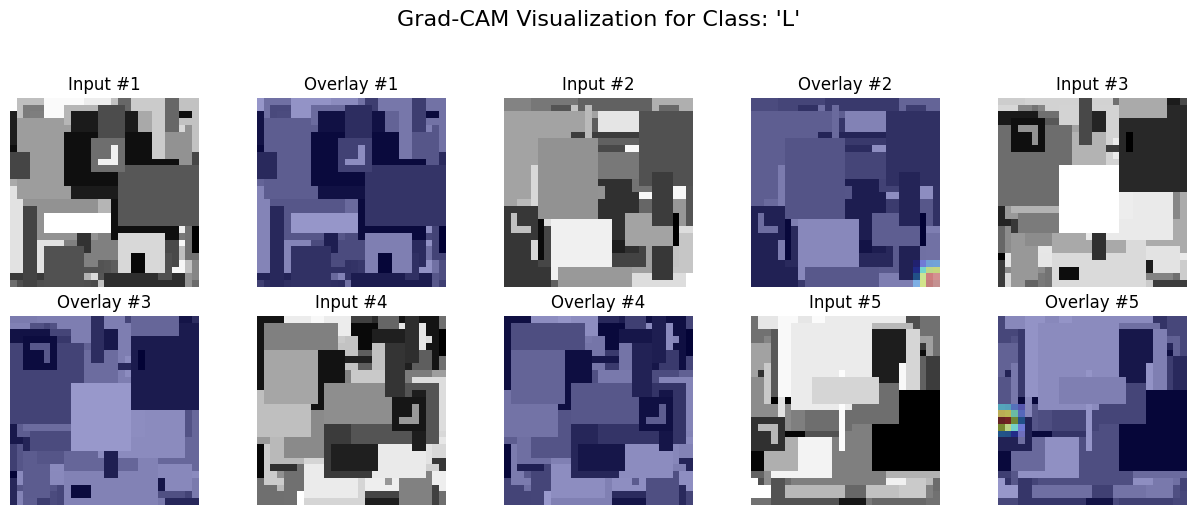

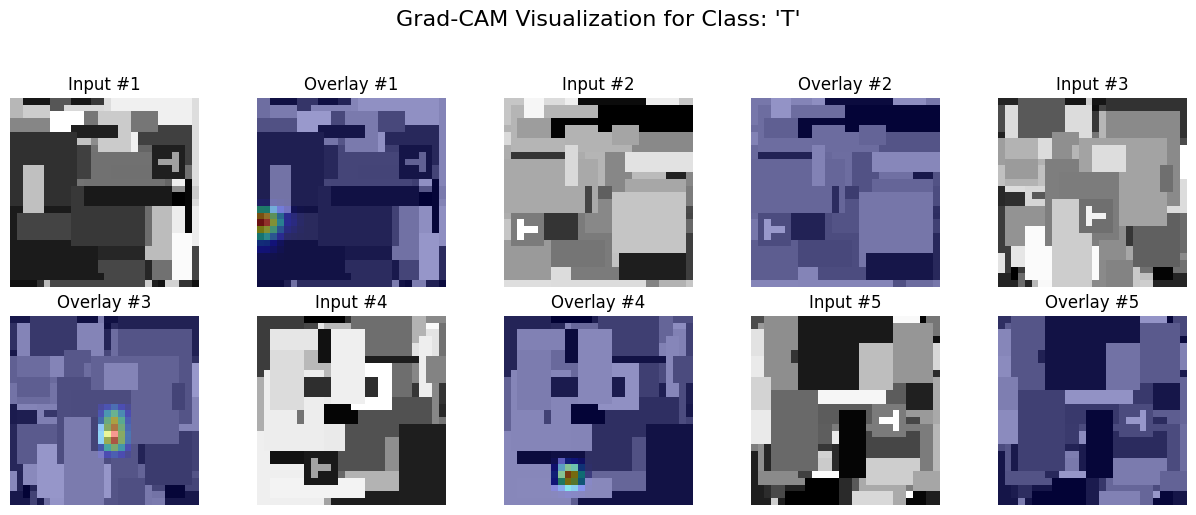

In [81]:
# 从验证集中为每个类别收集若干样本
num_examples_to_show = 5
samples_L, samples_T = [], []

# 从数据集中安全地提取样本（这行不要改动；它会自动适应上面修改的变量）
for images, labels in val_ds.unbatch().take(20000):  # .unbatch() 使得我们可以逐个处理样本
    label = labels.numpy()
    if label == 0 and len(samples_L) < num_examples_to_show:
        samples_L.append(images.numpy())
    elif label == 1 and len(samples_T) < num_examples_to_show:
        samples_T.append(images.numpy())
    if len(samples_L) == num_examples_to_show and len(samples_T) == num_examples_to_show:
        break

print(f"为 Grad-CAM 收集到 {len(samples_L)} 个 'L' 样本和 {len(samples_T)} 个 'T' 样本。")

# 可视化 'L' 类样本
# 将绘图列数调整为 5，以匹配样本数量
plot_samples_with_gradcam(final_model, samples_L, class_name='L', cols=num_examples_to_show)

# 可视化 'T' 类样本
# 将绘图列数调整为 5，以匹配样本数量
plot_samples_with_gradcam(final_model, samples_T, class_name='T', cols=num_examples_to_show)
